# COMP 352 Final Project - Spotify Predictions

### By Cameron McNamara, Bilal Adam, Maximo Babun

Requirements: 
  - There are four sections of the final project. You are expected to perform the following tasks within each section to fulfill the project requirements. Remember data science is cyclical in nature and requires multiple attempts and iterations. It is okay if your code moves between sections as you try different approaches, but at the end please try and organize your code into these sections for grading purposes.
- Data Importing and Pre-processing (100 Points)
  - Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
  - Clean, wrangle, and handle missing data, duplicate data, etc.
  - Encode any categorical variables
  - Perform feature engineering on the dataset
  - Transform data appropriately using techniques such as aggregation, normalization, and feature construction
  - Reduce redundant data and perform need based discretization
- Data Analysis and Visualization (100 Points)
  - Identify categorical, ordinal, and numerical variables within data
  - Provide measures of centrality and distribution with visualizations
  - Diagnose for correlations between variables and determine independent and dependent variables
  - Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest
  - Create visualizations that allow for the discovery of insights in the data

- Data Analytics (100 Points)
  - Determine the need for a supervised or unsupervised learning method and identify dependent and independent variables
  - Choose and provide reasoning for the selected metric or metrics employed to assess your model.
  - Train, test, cross validate, and provide performance metrics for model results
  - Try multiple different types of algorithms to determine the best model for your dataset
  - Analyze your model performance


First we must setup our environment to make sure we have all appropriate modules installed. To do this, I have provided 2 methods. The 1st, is to install all modules using a ```.yaml``` file via ```conda```. 

To do this, run:
```bash
conda env create -f env_setup/data_environment.yml
```
Then activate the environment by:
```bash
conda activate data_env
```

## 1. Data Importing and Pre-processing <a class="anchor" id="data-importing"></a>

In [4]:
# import libraries needed
import pandas as pd

pd.set_option("display.max_columns", None)
import warnings

import branca
import folium
import geopandas as gpd
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost as xgb
from branca.element import Figure
from folium import Marker
from folium.plugins import HeatMap
from scipy.special import boxcox1p
from scipy.stats import norm, probplot, skew
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from utils.model_utils import (
    time_series_split_regression,
    StackedEnsembleCVRegressor,
)
from utils.metrics_utils import (
    compute_rmse_std,
    print_rmse_and_dates,
)

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.*")
%matplotlib inline

In [51]:
## Import Data
spotify = pd.read_csv("SpotifyFeatures.csv")

#### Explore Dataset Dimensions

In [52]:
print(spotify.shape)
print("Total Observations:", spotify.shape[0])

(232725, 18)
Total Observations: 232725


In [53]:
cat_count = 0
for dtype in spotify.dtypes:
    if dtype == "object":
        cat_count = cat_count + 1

In [54]:
print("# of categorical variables:", cat_count)

numeric_vars = spotify.shape[1] - cat_count - 1
print("# of continous variables:", numeric_vars)

# of categorical variables: 7
# of continous variables: 10


#### Remove Unecessary Columns

In [55]:
spotify.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [56]:
# Remove Artist_name and track_name - high cardinality providing no predictive power.
spotify = spotify.drop(columns=["artist_name", "track_name"])

#### Check for missing values

In [57]:
total = spotify.isnull().sum().sort_values(ascending=False)
percent = (spotify.isnull().sum() / spotify.isnull().count()).sort_values(
    ascending=False
)
missing_data = pd.concat([total, percent], axis=1, keys=["Total", "Percent"])
missing_data.head(20)

,Total,Percent
genre,0,0.0
track_id,0,0.0
popularity,0,0.0
acousticness,0,0.0
danceability,0,0.0
duration_ms,0,0.0
energy,0,0.0
instrumentalness,0,0.0
key,0,0.0
liveness,0,0.0


In [58]:
# No Missing Values - Moving onto one-hot encoding of categorical variables

#### Handling outliers

This dataset includes every type of track. This includes dj sets, podcasts, symphonies, and other long audios. It also includes short tracks that are less than a minute long. We must remove these outliers from the dataset.

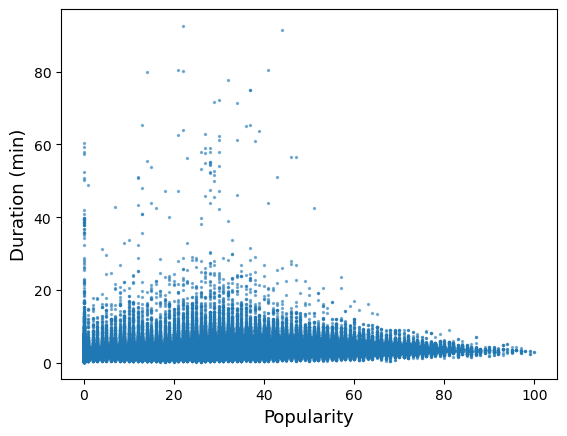

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(x=spotify["popularity"], y=spotify["duration_ms"]/1000/60, s=2, alpha=0.5)
plt.ylabel("Duration (min)", fontsize=13)
plt.xlabel("Popularity", fontsize=13)
plt.show()

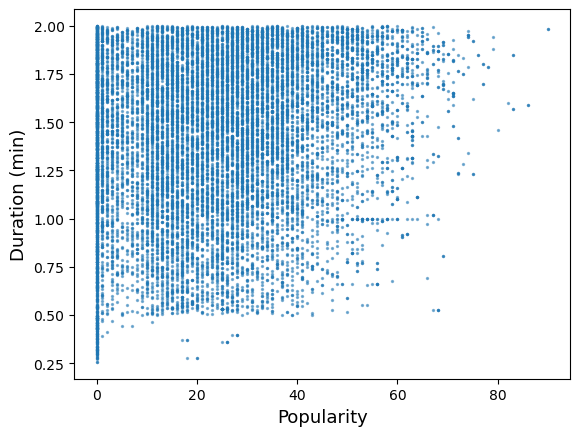

In [60]:
import matplotlib.pyplot as plt

# plot of duration vs popularity for songs less than 2 minutes
fig, ax = plt.subplots()
ax.scatter(x=spotify[spotify["duration_ms"] < 120000]["popularity"], y=spotify[spotify["duration_ms"] < 120000]["duration_ms"]/1000/60, s=2, alpha=0.5)
plt.ylabel("Duration (min)", fontsize=13)
plt.xlabel("Popularity", fontsize=13)
plt.show()

In [61]:
# remove tracks that are less than a minute or longer than 10 minutes
spotify = spotify[(spotify["duration_ms"] >= 60000) & (spotify["duration_ms"] <= 600000)]

In [62]:
spotify.shape

(228056, 16)

Removing tracks that are less than a minute and longer than 10 minutes will help focus on the actual songs while only removing 4,669 records.

#### Removing Highly correlated variables

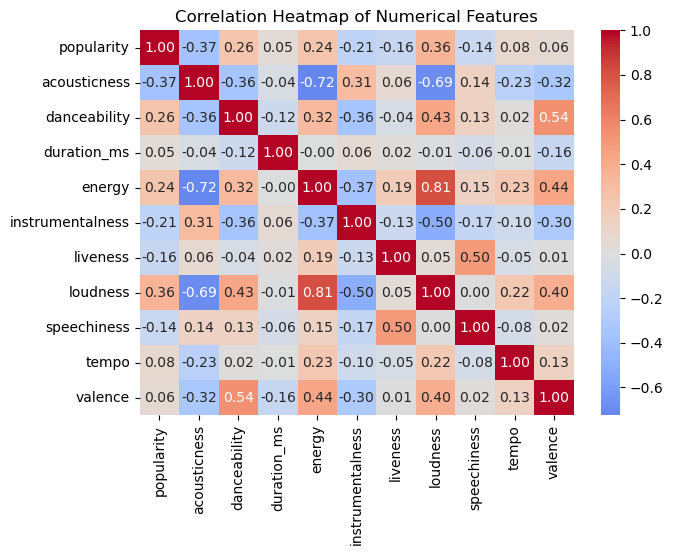

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = spotify.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(7, 5))
sns.heatmap(
    spotify[numerical_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

We see how energy and loudness have a high correlation index at 0.81. We drop one of the columns as this helps remove redundant information and it can improve interpretability.

In [64]:
spotify = spotify.drop(columns=['loudness'])

Drop loudness as energy captures both loudness and activity/intensity. 

#### Check for Duplicate Song IDs

In [65]:
spotify["track_id"].duplicated().sum()

np.int64(55735)

In [66]:
dup_ids = spotify[spotify["track_id"].duplicated(keep=False)]
dup_ids.sort_values("track_id").head(10)


,genre,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,mode,speechiness,tempo,time_signature,valence
110840,Pop,000xQL6tZNLJzIrtIgxqSl,70,0.1310,0.748,188491,0.627,0.00000,G,0.0852,Major,0.0644,120.963,4/4,0.524
14492,Dance,000xQL6tZNLJzIrtIgxqSl,70,0.1310,0.748,188491,0.627,0.00000,G,0.0852,Major,0.0644,120.963,4/4,0.524
153533,Rock,001gDjxhKGDSx4sMMAgS9R,58,0.0349,0.564,211789,0.808,0.00036,C#,0.3260,Major,0.0481,78.439,4/4,0.365
96926,Children’s Music,001gDjxhKGDSx4sMMAgS9R,57,0.0349,0.564,211789,0.808,0.00036,C#,0.3260,Major,0.0481,78.439,4/4,0.365
145387,Indie,001ifh9Zkyc5DhK7AGQRtK,42,0.4470,0.411,395573,0.422,0.12100,E,0.0742,Minor,0.0459,147.465,1/4,0.346
65253,Folk,001ifh9Zkyc5DhK7AGQRtK,42,0.4470,0.411,395573,0.422,0.12100,E,0.0742,Minor,0.0459,147.465,1/4,0.346
121130,Rap,002QT7AS6h1LAF5dla8D92,50,0.0469,0.830,207827,0.653,0.00000,C#,0.1120,Major,0.1850,123.032,4/4,0.228
90714,Hip-Hop,002QT7AS6h1LAF5dla8D92,50,0.0469,0.830,207827,0.653,0.00000,C#,0.1120,Major,0.1850,123.032,4/4,0.228
151359,Pop,002opcRBgYV5jqoh72QcqA,57,0.0508,0.707,181958,0.618,0.00000,A,0.1020,Major,0.1420,89.901,4/4,0.261
16593,Dance,002opcRBgYV5jqoh72QcqA,57,0.0508,0.707,181958,0.618,0.00000,A,0.1020,Major,0.1420,89.901,4/4,0.261


In [67]:
genre_dummies = pd.get_dummies(spotify["genre"], prefix="genre")
spotify_with_dummies = pd.concat([spotify, genre_dummies], axis=1)

# Group by track_id, taking max for genre columns (so all applicable genres = 1)
genre_cols = [col for col in spotify_with_dummies.columns if col.startswith("genre_")]

spotify_clean = spotify_with_dummies.groupby("track_id", as_index=False).agg(
    {
        **{
            col: "first"
            for col in spotify.columns
            if col not in ["track_id", "genre", "popularity"]
        },
        **{col: "max" for col in genre_cols},  # Max ensures all genres are captured
        "popularity": "mean",  # or 'max', your choice
    }
)

spotify=spotify_clean

In [68]:
spotify.head()
spotify.shape

(172321, 41)

There are 232,000 different records, however, certain songs appear more than once under different genres. In order to get around these duplicates, we only kept one observation per song id. In order to do this we created a one-hot encoded variables for genre, and aggregated them based on song_id. THis means taht if a song applies to more than one genre, they will have more than one TRUE for the binary encoded genre columns. In this aggregation we took the mean of the popularity of the two columns, if it was differing.

#### One-Hot Encode reamining cateogrical variables

In [69]:
cat_cols = ["key", "time_signature", "mode"]
spotify = pd.get_dummies(
    spotify,
    columns=cat_cols,
    prefix=cat_cols,
    drop_first=True
)

In [70]:
spotify.shape

(172321, 54)

In [71]:
spotify.head()

,track_id,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo,valence,genre_A Capella,genre_Alternative,genre_Anime,genre_Blues,genre_Children's Music,genre_Children’s Music,genre_Classical,genre_Comedy,genre_Country,genre_Dance,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Indie,genre_Jazz,genre_Movie,genre_Opera,genre_Pop,genre_R&B,genre_Rap,genre_Reggae,genre_Reggaeton,genre_Rock,genre_Ska,genre_Soul,genre_Soundtrack,genre_World,popularity,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,time_signature_1/4,time_signature_3/4,time_signature_4/4,time_signature_5/4,mode_Minor
0,00021Wy6AyMbLP2tqij86e,0.234,0.617,169173,0.862,0.976000,0.1410,0.0514,129.578,0.886,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,13.0,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False
1,000CzNKC8PEt1yC3L8dqwV,0.249,0.518,130653,0.805,0.000000,0.3330,0.0407,79.124,0.841,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,5.0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
2,000DfZJww8KiixTKuk9usJ,0.366,0.631,357573,0.513,0.000004,0.1090,0.0293,120.365,0.307,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,30.0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,000EWWBkYaREzsBplYjUag,0.815,0.768,104924,0.137,0.922000,0.1130,0.0747,76.430,0.560,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,39.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True
4,000xQL6tZNLJzIrtIgxqSl,0.131,0.748,188491,0.627,0.000000,0.0852,0.0644,120.963,0.524,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,70.0,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False


#### Feature Engineering

In [72]:
spotify["Hit"] = (spotify["popularity"] >= 70).astype(int)

Create Binary "Hit" column, classifying all songs with popularity >= 70 as a hit

In [74]:
spotify["tempo_fast"] = (spotify["tempo"] >= 120).astype(int)
spotify["tempo_slow"] = (spotify["tempo"] <= 90).astype(int)

Create banded very loud, very quiet, fast tempo, adn slow tempo, binary columns to help with hit classifcation. These are often penalized (i.e. very loud songs are not very popular, same with very quiet songs).

In [75]:
spotify["energy_dance"] = spotify["energy"] * spotify["danceability"]

Create an energy * dance feature to represent how danceable and energetic a song is, as many hits are both danceable and energetic

#### Scaling Continuous Variables

In [76]:
from sklearn.preprocessing import StandardScaler

continuous_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "speechiness",
    "valence",
    "tempo",
    "duration_ms",
    "energy_dance"
]

scaler = StandardScaler()
scaled_continuous_cols = scaler.fit_transform(spotify[continuous_cols])

Scale the data for continuous variables but not changing them into the spotify DF so that Data analysis and visualization is accurate.

## 2. Data analysis and Visualization


2.1: Identify categorical, ordinal, and numerical variables

In [77]:
numerical_cols = spotify.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = spotify.select_dtypes(include=["object", "bool"]).columns

len(numerical_cols), len(categorical_cols)

(14, 44)

In [78]:
numerical_cols

Index(['acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence',
       'popularity', 'Hit', 'tempo_fast', 'tempo_slow', 'energy_dance'],
      dtype='object')

In [79]:
categorical_cols

Index(['track_id', 'genre_A Capella', 'genre_Alternative', 'genre_Anime',
       'genre_Blues', 'genre_Children's Music', 'genre_Children’s Music',
       'genre_Classical', 'genre_Comedy', 'genre_Country', 'genre_Dance',
       'genre_Electronic', 'genre_Folk', 'genre_Hip-Hop', 'genre_Indie',
       'genre_Jazz', 'genre_Movie', 'genre_Opera', 'genre_Pop', 'genre_R&B',
       'genre_Rap', 'genre_Reggae', 'genre_Reggaeton', 'genre_Rock',
       'genre_Ska', 'genre_Soul', 'genre_Soundtrack', 'genre_World', 'key_A#',
       'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F',
       'key_F#', 'key_G', 'key_G#', 'time_signature_1/4', 'time_signature_3/4',
       'time_signature_4/4', 'time_signature_5/4', 'mode_Minor'],
      dtype='object')

#### Variable Types

- **Numerical variables** include audio features such as popularity, tempo, loudness, energy, danceability, and duration.
- **Categorical variables** include identifiers and encoded genre and musical attributes.
- No ordinal variables are explicitly present in this dataset.

### 2.2 Provide measures of centrality and distribution with visualizations

In [80]:
spotify[numerical_cols].describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo,valence,popularity,Hit,tempo_fast,tempo_slow,energy_dance
count,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000,172321.000000
mean,0.395665,0.543612,230442.191950,0.562015,0.167358,0.222469,0.124011,117.487719,0.453821,36.808637,0.022742,0.451112,0.219474,0.324100
std,0.363905,0.189123,84489.268029,0.273747,0.319172,0.208420,0.198227,31.270748,0.266757,17.409265,0.149082,0.497606,0.413892,0.188255
min,0.000000,0.057000,60000.000000,0.000020,0.000000,0.009670,0.022200,30.379000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000002
25%,0.043200,0.419000,179747.000000,0.355000,0.000000,0.097400,0.036700,92.168000,0.226000,26.000000,0.000000,0.000000,0.000000,0.171536
50%,0.273000,0.560000,219581.000000,0.598000,0.000065,0.130000,0.049300,115.192000,0.443000,38.000000,0.000000,0.000000,0.000000,0.342342
75%,0.777000,0.685000,267040.000000,0.792000,0.075900,0.274000,0.100000,139.169000,0.668000,49.000000,0.000000,1.000000,0.000000,0.468356
max,0.996000,0.989000,600000.000000,0.999000,0.998000,1.000000,0.967000,242.903000,1.000000,100.000000,1.000000,1.000000,1.000000,0.895856


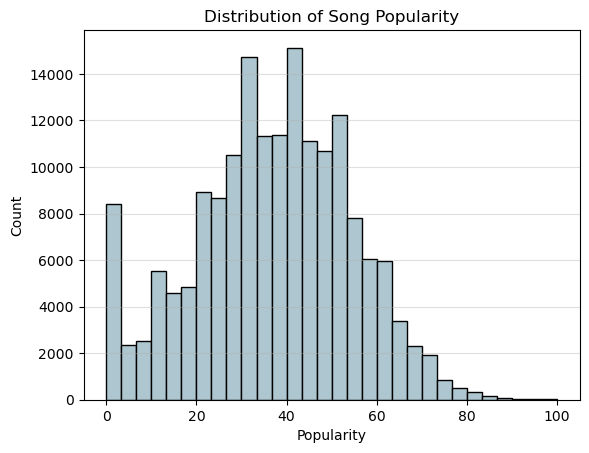

In [81]:
import matplotlib.pyplot as plt

plt.hist(
    spotify["popularity"],
    bins=30,
    color="#AEC6CF",
    edgecolor="black"
)

plt.xlabel("Popularity")
plt.ylabel("Count")
plt.title("Distribution of Song Popularity")
plt.grid(axis="y", alpha=0.4)

plt.show()

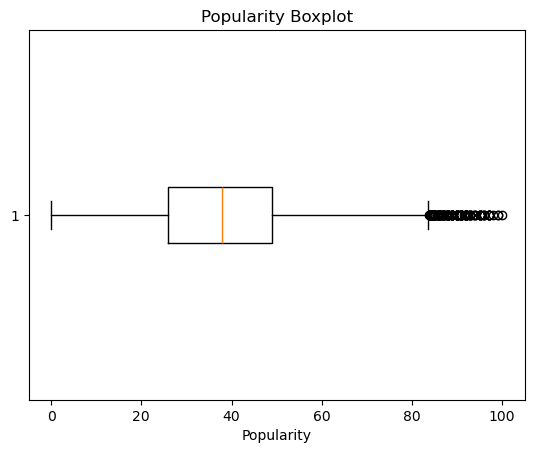

In [82]:
plt.boxplot(spotify["popularity"], vert=False)
plt.xlabel("Popularity")
plt.title("Popularity Boxplot")
plt.show()

The popularity variable is right-skewed, with most songs having lower popularity values.
A small number of songs appear as outliers with very high popularity.

### 2.3: Correlations + Independent Dependent Variable

In [83]:
corr_matrix = spotify[numerical_cols].corr()
corr_matrix

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo,valence,popularity,Hit,tempo_fast,tempo_slow,energy_dance
acousticness,1.000000,-0.376440,-0.043515,-0.729648,0.299997,0.074968,0.165794,-0.256620,-0.348175,-0.350646,-0.072395,-0.200932,0.276801,-0.667526
danceability,-0.376440,1.000000,-0.115524,0.358909,-0.361188,-0.031415,0.128843,0.040359,0.582168,0.223371,0.093378,0.027354,-0.242264,0.726115
duration_ms,-0.043515,-0.115524,1.000000,0.002692,0.056449,0.020118,-0.061813,-0.004753,-0.165000,0.065976,-0.018900,0.017014,0.001669,-0.043117
energy,-0.729648,0.358909,0.002692,1.000000,-0.384587,0.208399,0.165025,0.240175,0.450109,0.226511,0.046283,0.173399,-0.258390,0.854846
instrumentalness,0.299997,-0.361188,0.056449,-0.384587,1.000000,-0.158968,-0.185179,-0.107227,-0.326256,-0.147905,-0.074554,-0.070964,0.114345,-0.396576
liveness,0.074968,-0.031415,0.020118,0.208399,-0.158968,1.000000,0.547700,-0.058746,0.002646,-0.159840,-0.037264,-0.045556,0.071371,0.109312
speechiness,0.165794,0.128843,-0.061813,0.165025,-0.185179,0.547700,1.000000,-0.096100,0.012225,-0.153165,-0.011262,-0.081099,0.146116,0.155928
tempo,-0.256620,0.040359,-0.004753,0.240175,-0.107227,-0.058746,-0.096100,1.000000,0.156546,0.077581,0.019214,0.829358,-0.656670,0.142371
valence,-0.348175,0.582168,-0.165000,0.450109,-0.326256,0.002646,0.012225,0.156546,1.000000,0.047230,0.026406,0.085678,-0.199180,0.585569
popularity,-0.350646,0.223371,0.065976,0.226511,-0.147905,-0.159840,-0.153165,0.077581,0.047230,1.000000,0.334824,0.066251,-0.110006,0.266467


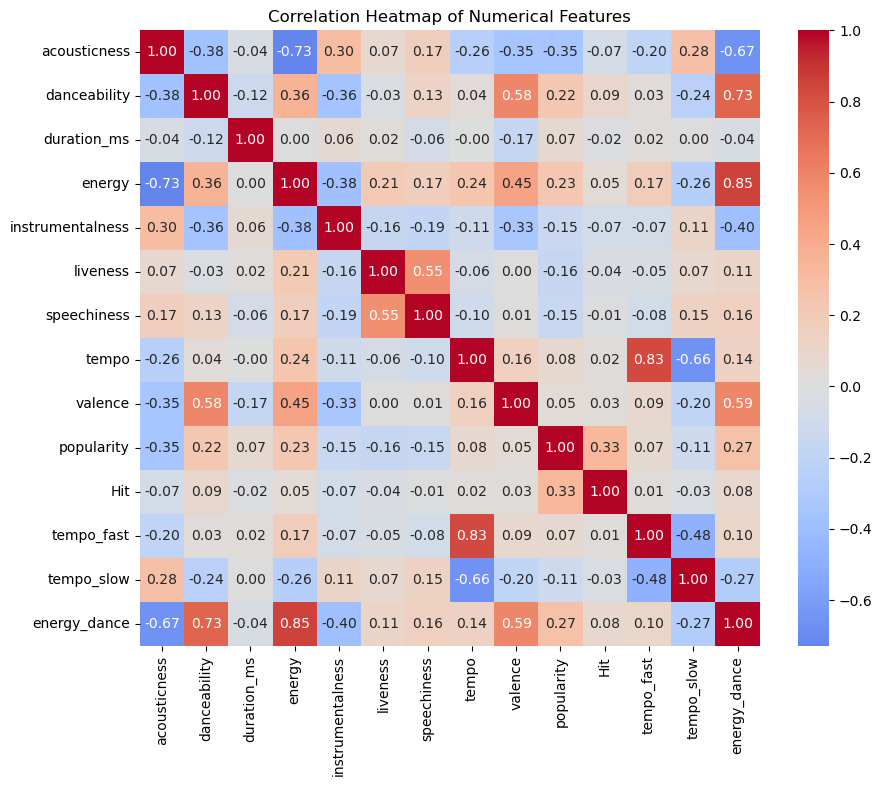

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Several audio features, including energy and danceability, show noticeable positive relationships with popularity. Louder and more energetic songs tend to achieve higher popularity scores, while acousticness shows a weaker or negative relationship. These patterns suggest that production intensity and rhythmic qualities may play an important role in song popularity.

### Independent and Dependent Variables

Dependent variable:
 - Regression Tasks: Popularity, which represents the overall success of a song on Spotify.
 - Classification (XGboost) Tasks: Genre

Independent variables:
Audio characteristics such as loudness, energy, danceability, tempo, genre (For regression only), scale, acousticness, etc. which describe the musical and production qualities of each track and may influence its popularity.

### 2.4: EDA/Visualizations


Exploratory analysis shows that hit songs tend to cluster around higher values of
danceability and energy, while extremely low popularity songs dominate the dataset.

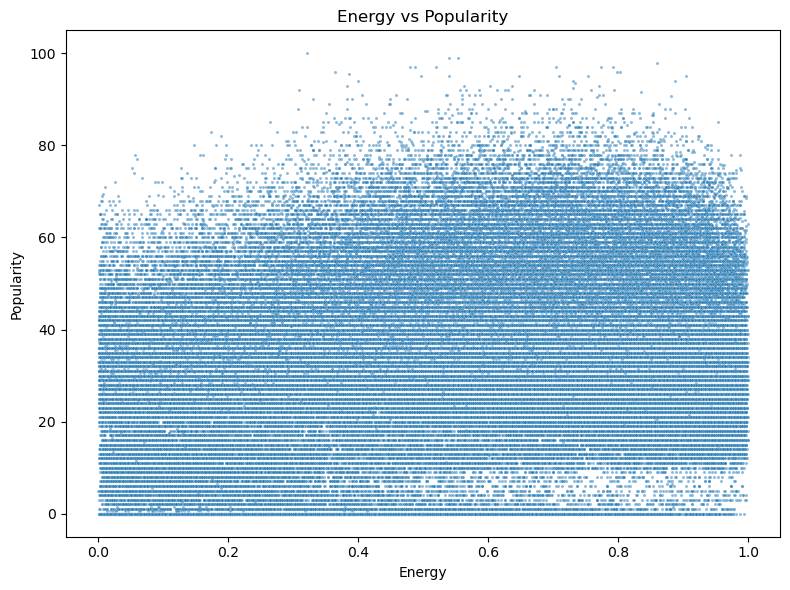

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=spotify,
    x="energy",
    y="popularity",
    s=5,
    alpha=0.5
)

plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.tight_layout()
plt.show()

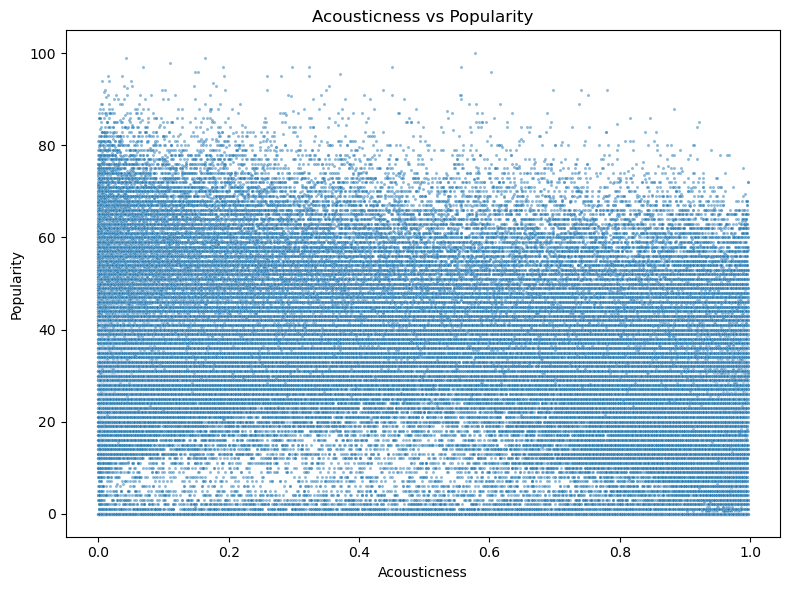

In [90]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=spotify,
    x="acousticness",
    y="popularity",
    s=5,
    alpha=0.5
)

plt.title("Acousticness vs Popularity")
plt.xlabel("Acousticness")
plt.ylabel("Popularity")
plt.tight_layout()
plt.show()

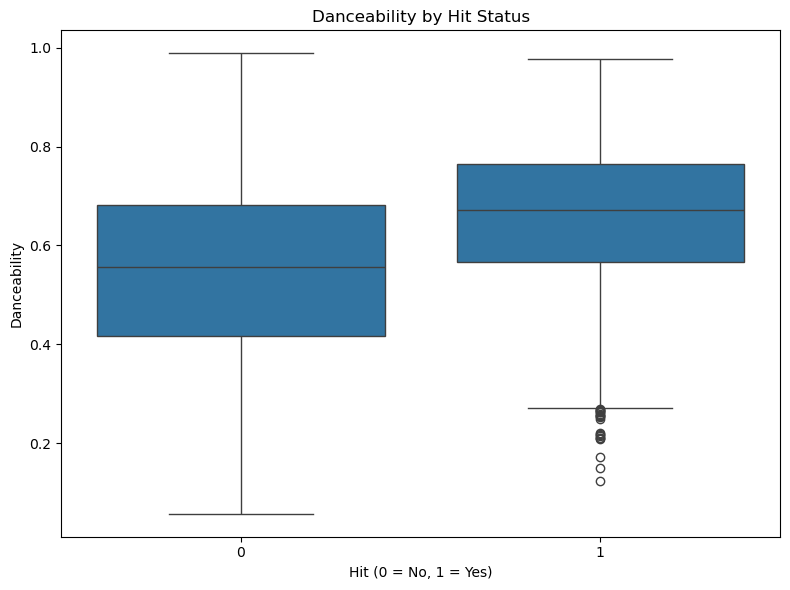

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(
    x="Hit",
    y="danceability",
    data=spotify
)

plt.title("Danceability by Hit Status")
plt.xlabel("Hit (0 = No, 1 = Yes)")
plt.ylabel("Danceability")
plt.tight_layout()
plt.show()

Hit songs tend to have higher energy and danceability than non hit songs, suggesting that these features are strongly associated with a song’s popularity.

## 3. Modeling

In [92]:
# Update spotify df to use the scaled continuous variables
continuous_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "speechiness",
    "valence",
    "tempo",
    "duration_ms",
    "energy_dance"
]

spotify[continuous_cols] = scaled_continuous_cols

### (Supervised) Logistic Regression Hit Prediction

##### We made two logistic regression models. The first uses a train set that has a 50/50 split in hit/non-hit data (~3k ea). The second uses 5 Fold CV with Class weights 

#### Prepare Data 

In [93]:
# Drop columns that shouldn't be used for prediction
# Keep all the genre_* columns since they're predictive
X = spotify.drop(columns=['Hit', 'popularity', 'track_id'])  
y = spotify['Hit']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (172321, 55)
Target shape: (172321,)
Target distribution:
Hit
0    168402
1      3919
Name: count, dtype: int64


#### Scaling the Data

In [94]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [95]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#### Logistic Model 1 - 50/50 Split

In [96]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)  # 1.0 = 50/50

X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print("Balanced training set:")
print(f"Hits: {y_train_bal.sum()}")
print(f"Non-hits: {len(y_train_bal) - y_train_bal.sum()}")

Balanced training set:
Hits: 3135
Non-hits: 3135


In [97]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, random_state=42)

log_reg.fit(X_train_bal, y_train_bal)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.8976
Precision: 0.1670
Recall   : 0.8776
F1-score : 0.2806
ROC-AUC  : 0.9454


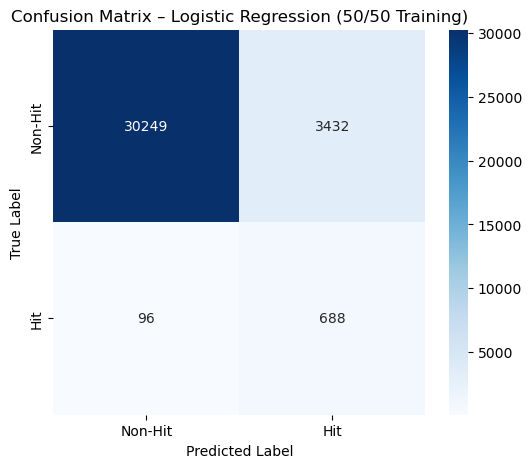

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Non-Hit", "Hit"],
            yticklabels=["Non-Hit", "Hit"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.title("Confusion Matrix – Logistic Regression (50/50 Training)")
plt.show()

#### Stratified K-Fold CV Logistic Model

In [108]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
precision_scores = []
recall_scores = []
auc_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    log_reg_cw = LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=42
    )

    log_reg_cw.fit(X_train, y_train)

    y_val_prob = log_reg_cw.predict_proba(X_val)[:, 1]
    y_val_pred = log_reg_cw.predict(X_val)

    accuracy_scores.append(accuracy_score(y_val, y_val_pred))
    precision_scores.append(precision_score(y_val, y_val_pred))
    recall_scores.append(recall_score(y_val, y_val_pred))
    auc_scores.append(roc_auc_score(y_val, y_val_prob))
    f1_scores.append(f1_score(y_val, y_val_pred))

In [109]:
print("Class-Weighted Logistic Regression (CV)")
print(f"Mean accuracy_score: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Mean precision_score: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Mean recall_score: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"Mean ROC-AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Mean F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

Class-Weighted Logistic Regression (CV)
Mean accuracy_score: 0.8970 ± 0.0026
Mean precision_score: 0.1671 ± 0.0044
Mean recall_score: 0.8857 ± 0.0106
Mean ROC-AUC: 0.9479 ± 0.0041
Mean F1-Score: 0.2812 ± 0.0066


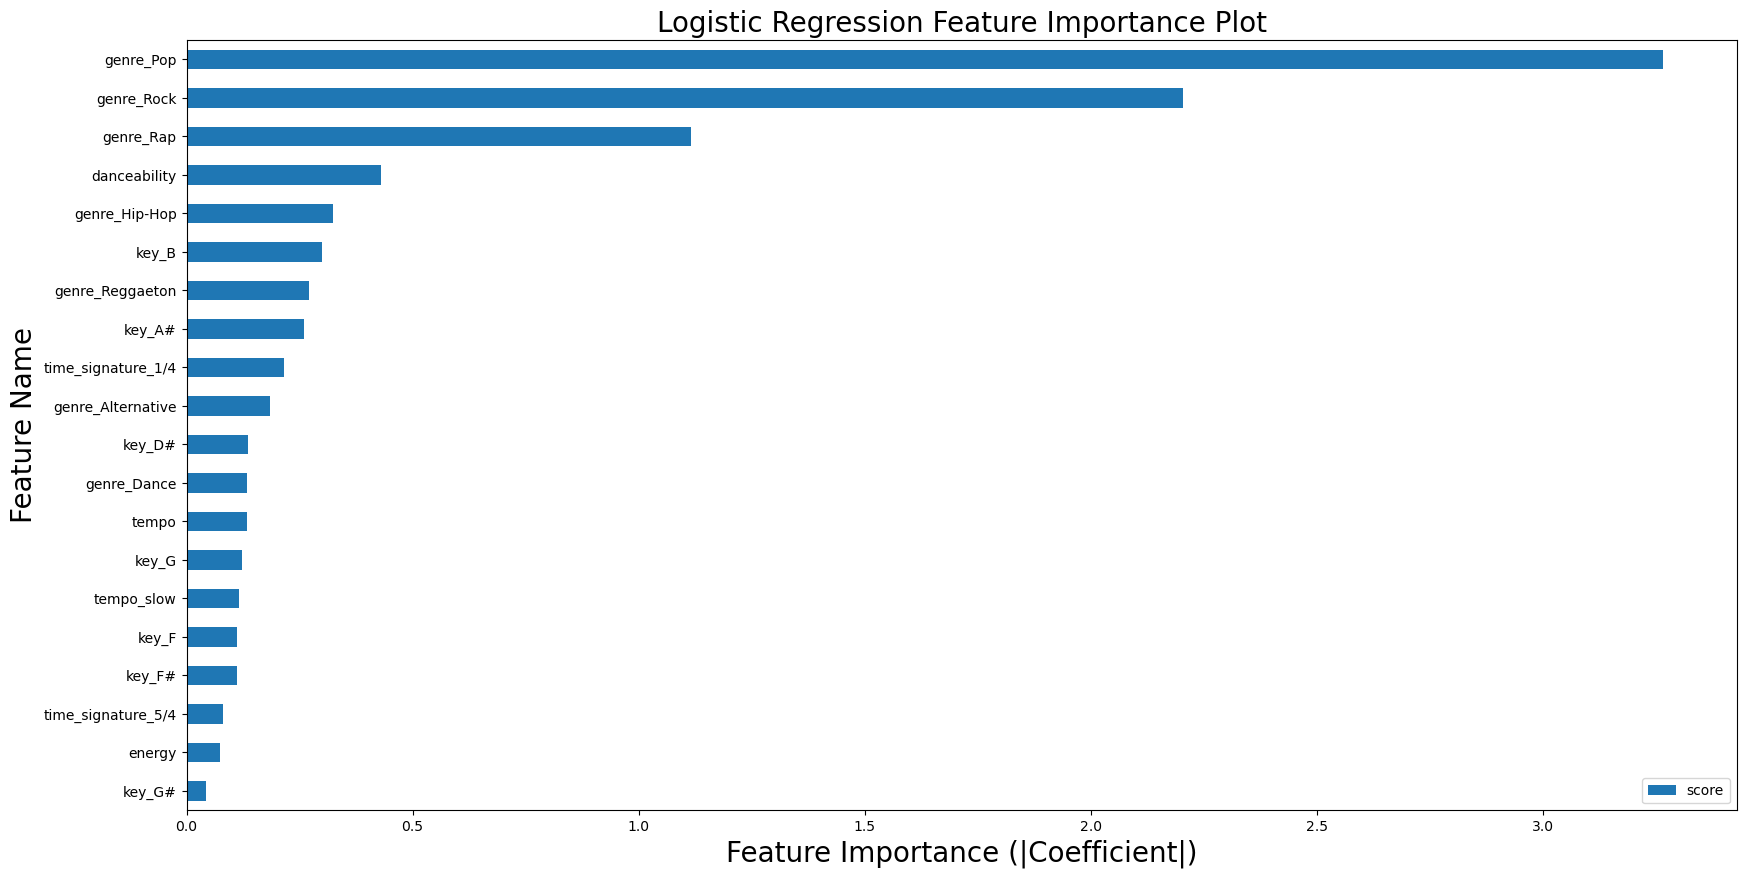

In [110]:
import numpy as np
# Feature Importance from Logistic Regression Coefficients
coefficients = log_reg.coef_[0] 
feature_names = X.columns

# Create DataFrame for feature importance format
data = pd.DataFrame(data=coefficients, index=feature_names, columns=["score"]).sort_values(
    by="score", ascending=False
)

# Plot top 20 features
data[:20].plot(kind="barh", figsize=(20, 10)).invert_yaxis()
plt.xlabel("Feature Importance (|Coefficient|)", fontsize=20)
plt.ylabel("Feature Name", fontsize=20)
plt.title("Logistic Regression Feature Importance Plot", fontsize=20)
plt.show()

### (Unsupervised) K-means clustering

In [111]:
continuous_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "speechiness",
    "valence",
    "tempo",
    "duration_ms",
    "energy_dance"
]

spotify[continuous_cols].describe()

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,tempo,duration_ms,energy_dance
count,1.723210e+05,1.723210e+05,1.723210e+05,1.723210e+05,1.723210e+05,1.723210e+05,1.723210e+05,1.723210e+05,1.723210e+05,1.723210e+05
mean,2.012409e-16,3.977400e-16,7.783886e-17,-3.434765e-17,-1.474722e-16,-1.855515e-18,4.154885e-16,6.489355e-16,1.356175e-16,-4.155323e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.087280e+00,-2.572998e+00,-2.052981e+00,-5.243505e-01,-1.021012e+00,-5.136089e-01,-1.701262e+00,-2.785638e+00,-2.017329e+00,-1.721588e+00
25%,-9.685672e-01,-6.588973e-01,-7.562319e-01,-5.243505e-01,-6.000815e-01,-4.404602e-01,-8.540449e-01,-8.096958e-01,-6.000210e-01,-8.104109e-01
50%,-3.370819e-01,8.665026e-02,1.314531e-01,-5.241459e-01,-4.436661e-01,-3.768966e-01,-4.056675e-02,-7.341447e-02,-1.285515e-01,9.690177e-02
75%,1.047899e+00,7.475967e-01,8.401399e-01,-2.865470e-01,2.472485e-01,-1.211285e-01,8.029014e-01,6.933427e-01,4.331664e-01,7.662817e-01
max,1.649706e+00,2.355018e+00,1.596316e+00,2.602499e+00,3.730610e+00,4.252657e+00,2.047486e+00,4.010638e+00,4.374033e+00,3.037140e+00


In [112]:
X_cluster = spotify[continuous_cols]

In [113]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

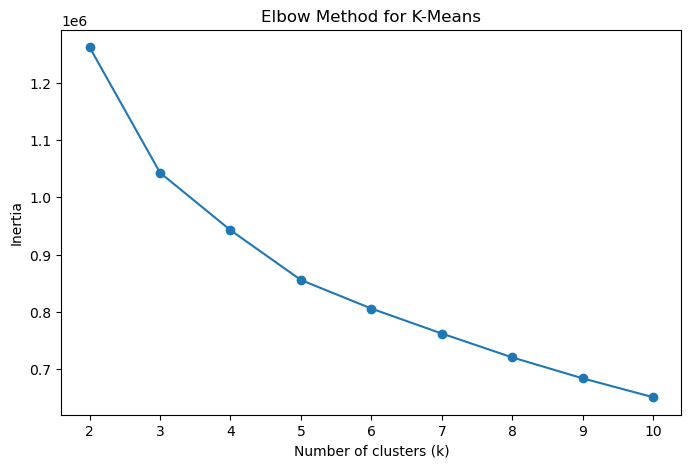

In [114]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

k=2, silhouette=0.281
k=3, silhouette=0.317
k=4, silhouette=0.197
k=5, silhouette=0.192
k=6, silhouette=0.172
k=7, silhouette=0.176
k=8, silhouette=0.179
k=9, silhouette=0.183
k=10, silhouette=0.184


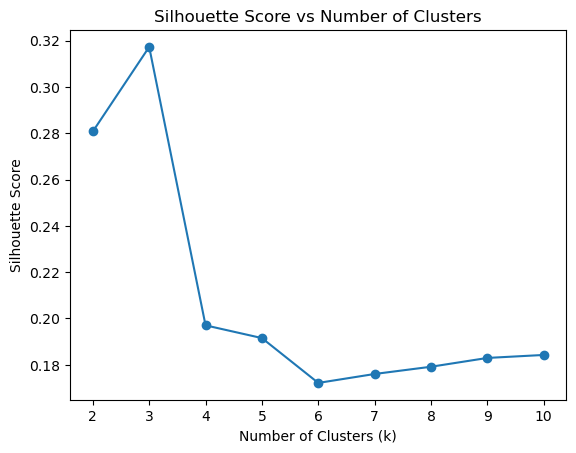

In [115]:
from sklearn.metrics import silhouette_score

X_sil = X_cluster.sample(n=10000, random_state=42)

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sil)
    score = silhouette_score(X_sil, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette={score:.3f}")

# Plot
plt.figure()
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

k=2, silhouette=0.281
k=3, silhouette=0.317
k=4, silhouette=0.197
k=5, silhouette=0.192
k=6, silhouette=0.172
k=7, silhouette=0.176
k=8, silhouette=0.179
k=9, silhouette=0.183
k=10, silhouette=0.184


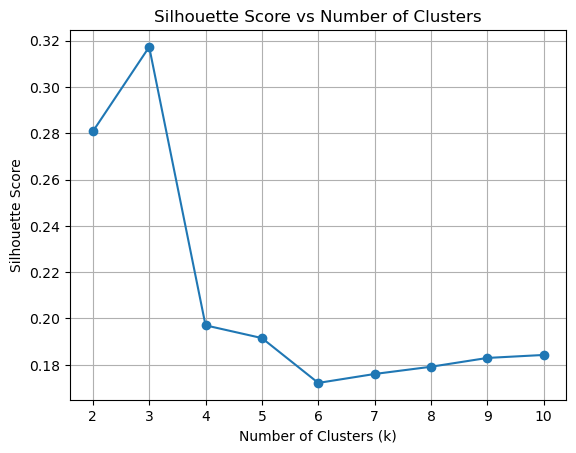

In [116]:
X_sil = X_cluster.sample(n=10000, random_state=42)

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sil)
    score = silhouette_score(X_sil, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette={score:.3f}")

# Plot
plt.figure()
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_values)
plt.grid(True)
plt.show()

Given this elbow plot with intertia, we were looking at choosing k=5. There was no sharp elbow or inflection point, but after k=5, the returns seemed to dimish slightly. We ran a silouhette score comparison across all k values as well, to double check our choice. We found that the highest silouhette score was at 0.342 at k = 3. Given these results we decided to run two models with differing K values to see if we could get a well performing 3 bucket seperation, and a lower performing but higher interpretability 5 bucket seperation.

#### K = 3 K Means Model

In [117]:
k_opt = 3
kmeans_3 = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
spotify["cluster_3"] = kmeans_3.fit_predict(X_cluster)

In [118]:
spotify.groupby("cluster_3")[continuous_cols].mean()
spotify.groupby("cluster_3")[genre_cols].mean()

,genre_A Capella,genre_Alternative,genre_Anime,genre_Blues,genre_Children's Music,genre_Children’s Music,genre_Classical,genre_Comedy,genre_Country,genre_Dance,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Indie,genre_Jazz,genre_Movie,genre_Opera,genre_Pop,genre_R&B,genre_Rap,genre_Reggae,genre_Reggaeton,genre_Rock,genre_Ska,genre_Soul,genre_Soundtrack,genre_World
cluster_3,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.003288,0.000110,0.002740,0.013371,0.002959,0.001644,0.908483,0.001315,0.000658,0.003178,0.001096,0.010083,0.001644,0.003288,0.035620,0.003946,0.002521,0.004822,0.008549,0.002082,0.001644,0.000658,0.003507,0.002192,0.000438,0.000986
1,0.001854,0.019693,0.050648,0.035327,0.029628,0.020845,0.150148,0.003298,0.024748,0.007241,0.018405,0.076860,0.003982,0.049262,0.077172,0.082149,0.152803,0.018932,0.027871,0.004645,0.004548,0.000390,0.023011,0.002362,0.039991,0.174077,0.078519
2,0.000214,0.073302,0.055171,0.063147,0.029082,0.073579,0.006082,0.003323,0.065916,0.074285,0.074276,0.047463,0.080180,0.062486,0.047409,0.025259,0.000080,0.074901,0.066943,0.079519,0.075830,0.079054,0.072052,0.076920,0.062272,0.002912,0.042810


In [119]:
spotify.groupby("cluster_3")[continuous_cols].mean()

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,tempo,duration_ms,energy_dance
cluster_3,,,,,,,,,,
0,1.087265,0.081009,0.407493,-0.519851,2.477134,3.790434,-0.180852,-0.618896,-0.140716,0.235114
1,1.065041,-0.887849,-1.184437,0.715731,-0.254899,-0.367730,-0.836672,-0.314547,0.055087,-1.213921
2,-0.575992,0.399699,0.508819,-0.285171,-0.085220,-0.140611,0.397619,0.194379,-0.013742,0.536359


Cluster	Description
- 0	Instrumental, classical, and cinematic music
- 1 Spoken / Comedy / Non-musical audio
- 2	Mainstream, genre-blending popular music

##### K-Means k=3 evaluation

In [120]:
labels = kmeans_3.fit_predict(X_cluster)
score = silhouette_score(X_cluster, labels)
print("Kmeans_3 Intertia:", kmeans_3.inertia_)
print("Kmeans_3 Sillouttte Score:", score)

Kmeans_3 Intertia: 1043038.4188294918
Kmeans_3 Sillouttte Score: 0.3196169421205367


Kmeans_3 Intertia: 1147732.3986595399
Kmeans_3 Sillouttte Score: 0.3485772304273481

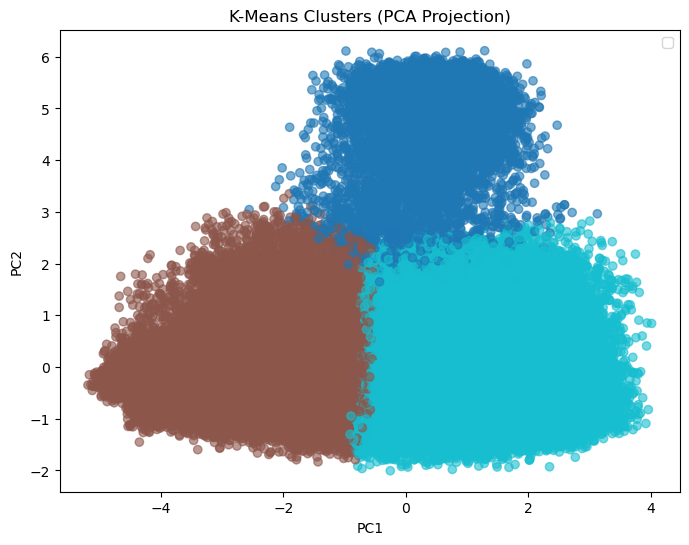

In [121]:

# wanted to visualize features on 2 dimensional graph so used PCA to get principal features adn visualzied 3 clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=spotify["cluster_3"], cmap="tab10", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Projection)")
plt.legend()
plt.show()

#### K = 5 K means model

In [122]:
k_opt = 5
kmeans_5 = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
spotify["cluster_5"] = kmeans_5.fit_predict(X_cluster)

In [123]:
spotify.groupby("cluster_5")[continuous_cols].mean()
spotify.groupby("cluster_5")[genre_cols].mean()

,genre_A Capella,genre_Alternative,genre_Anime,genre_Blues,genre_Children's Music,genre_Children’s Music,genre_Classical,genre_Comedy,genre_Country,genre_Dance,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Indie,genre_Jazz,genre_Movie,genre_Opera,genre_Pop,genre_R&B,genre_Rap,genre_Reggae,genre_Reggaeton,genre_Rock,genre_Ska,genre_Soul,genre_Soundtrack,genre_World
cluster_5,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.003059,0.034998,0.023152,0.061568,0.047114,0.037157,0.060459,0.007917,0.053681,0.018863,0.008877,0.122837,0.014275,0.081481,0.079712,0.114590,0.172350,0.039496,0.060819,0.015295,0.011756,0.003269,0.039286,0.005368,0.078423,0.021143,0.064148
1,0.000000,0.004453,0.081582,0.008060,0.019638,0.004097,0.253295,0.000000,0.000267,0.001247,0.023913,0.018169,0.000267,0.012959,0.073922,0.043552,0.093427,0.002449,0.003429,0.000980,0.000802,0.000000,0.005834,0.000356,0.008906,0.362976,0.070716
2,0.000223,0.052223,0.033886,0.051602,0.040848,0.053259,0.001227,0.003298,0.062770,0.083035,0.056955,0.038204,0.102726,0.055186,0.054167,0.026128,0.000000,0.084086,0.072600,0.094665,0.109783,0.120856,0.059392,0.071198,0.065765,0.001306,0.017971
3,0.000000,0.002454,0.000000,0.001785,0.012828,0.002454,0.001339,0.922476,0.000892,0.000335,0.002454,0.000781,0.008924,0.000892,0.003012,0.031344,0.003123,0.002008,0.003904,0.007474,0.001785,0.001227,0.000446,0.002119,0.002008,0.000223,0.000446
4,0.000067,0.104475,0.090251,0.076274,0.004577,0.103537,0.013308,0.001987,0.065110,0.063011,0.108471,0.052539,0.050529,0.068213,0.034542,0.014335,0.000022,0.060532,0.050685,0.059795,0.031818,0.026348,0.091078,0.091323,0.046443,0.006899,0.088554


In [124]:
spotify.groupby("cluster_5")[continuous_cols].mean()

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,tempo,duration_ms,energy_dance
cluster_5,,,,,,,,,,
0,0.985833,-0.437899,-1.012132,-0.411674,-0.173340,-0.317097,-0.520148,-0.266709,-0.040872,-0.994019
1,1.134623,-1.212312,-1.332260,2.076700,-0.388400,-0.392728,-1.040795,-0.423543,0.045223,-1.349348
2,-0.526607,0.855080,0.486594,-0.326111,-0.205749,-0.105838,0.815954,-0.100333,-0.171173,0.849885
3,1.097614,0.086715,0.415518,-0.520883,2.482706,3.833060,-0.184579,-0.630223,-0.144532,0.245946
4,-0.784557,-0.281885,0.656425,-0.173441,0.115195,-0.185936,-0.197505,0.677717,0.276592,0.176287


In [125]:
labels_5 = kmeans_5.fit_predict(X_cluster)
score = silhouette_score(X_cluster, labels_5)
print("Kmeans_3 Intertia:", kmeans_3.inertia_)
print("Kmeans_3 Sillouttte Score:", score)

Kmeans_3 Intertia: 1043038.4188294918
Kmeans_3 Sillouttte Score: 0.191063552983185


Kmeans_3 Intertia: 1147732.3986595399
Kmeans_3 Sillouttte Score: 0.1875342916530692

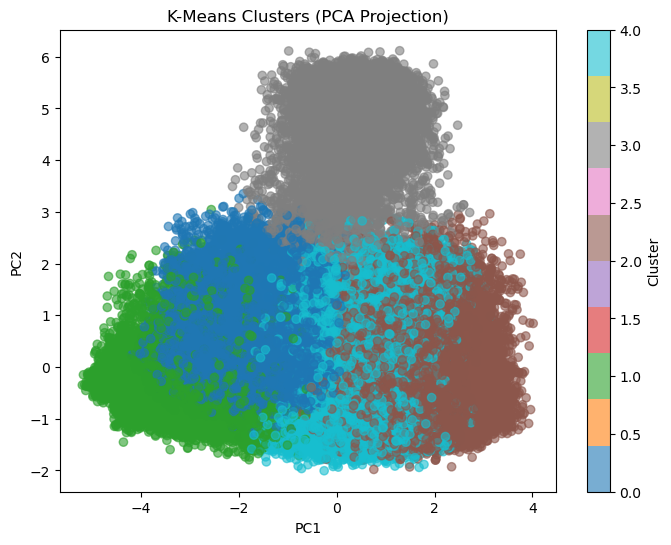

In [126]:
# wanted to visualize features on 2 dimensional graph so used PCA to get principal features and visualzied 5 clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=spotify["cluster_5"], cmap="tab10", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()

### (Supervised) XGBoost Genre predictions

 * Each song can belong to multiple genres

In [127]:
genre_cols = [c for c in spotify.columns if c.startswith("genre_")]
y = spotify[genre_cols]

In [128]:
X = spotify.drop(columns=genre_cols + ["track_id", "popularity", "Hit", "cluster_3", "cluster_5"])

In [129]:
# test train split 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [131]:
# cross validation - used a multi-label stratifcation package from iterstrat in order to keep
# consistent representation of all genres across folds
from sklearn.model_selection import KFold
import numpy as np
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [132]:
# define model
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier

xgb_base = OneVsRestClassifier(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)


In [133]:
#define tuning grid and tune
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

param_grid = {
    "estimator__max_depth": [4, 6],
    "estimator__n_estimators": [150, 250],
    "estimator__learning_rate": [0.05, 0.1],
}


def micro_f1_from_proba(estimator, X, y_true):
    y_proba = estimator.predict_proba(X)
    y_pred = (y_proba >= 0.5).astype(int)
    return f1_score(y_true, y_pred, average="micro")

#use 5 cross fold to tune
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=micro_f1_from_proba,
    cv=mskf,
    verbose=1,
    n_jobs=-1,
)

In [134]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,"OneVsRestClas...ee=None, ...))"
,param_grid,"{'estimator__learning_rate': [0.05, 0.1], 'estimator__max_depth': [4, 6], 'estimator__n_estimators': [150, 250]}"
,scoring,<function mic...0021858D0C790>
,n_jobs,-1
,refit,True
,cv,MultilabelStr... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [135]:
print("Best params:", grid.best_params_)
print("Best CV Micro F1:", grid.best_score_)

Best params: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 6, 'estimator__n_estimators': 250}
Best CV Micro F1: 0.32452278603922396


Best params: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 6, 'estimator__n_estimators': 250}
Best CV Micro F1: 0.34316938597394303

In [139]:
best_xgb = grid.best_estimator_

best_xgb.fit(X_train, y_train)

y_test_proba = best_xgb.predict_proba(X_test)
y_test_pred = (y_test_proba >= 0.4).astype(int)

from sklearn.metrics import f1_score, hamming_loss

print("Final Test Performance (XGBoost)")
print("Micro F1:", f1_score(y_test, y_test_pred, average="micro"))
print("Macro F1:", f1_score(y_test, y_test_pred, average="macro"))
print("Hamming:", hamming_loss(y_test, y_test_pred))

Final Test Performance (XGBoost)
Micro F1: 0.3741139161795797
Macro F1: 0.3202236916060731
Hamming: 0.043266652696509075


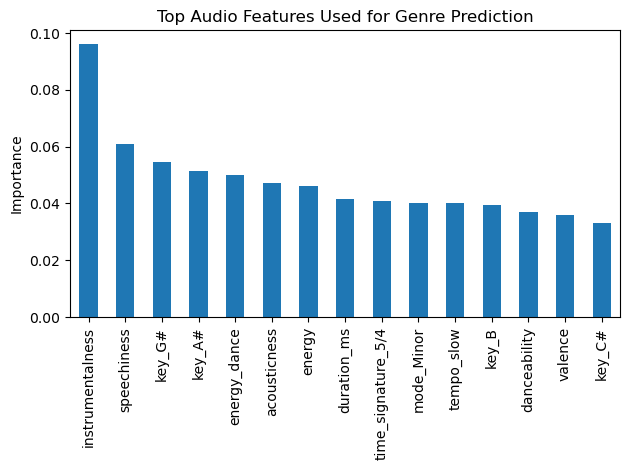

In [140]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from first estimator
booster = best_xgb.estimators_[0]
importances = booster.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure()
feat_imp.head(15).plot(kind="bar")
plt.title("Top Audio Features Used for Genre Prediction")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

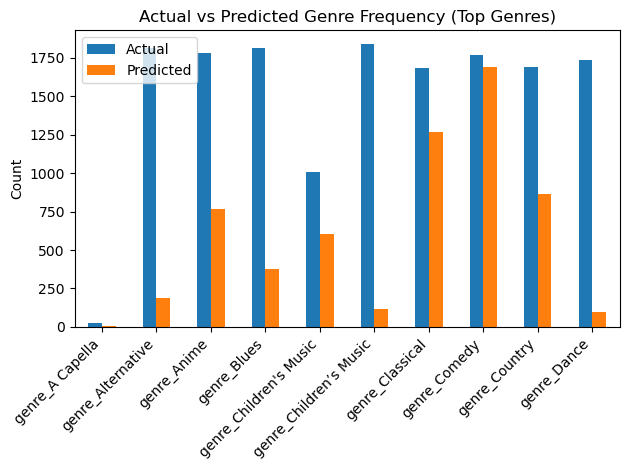

In [141]:
true_counts = y_test.sum().sort_values(ascending=False)
pred_counts = pd.DataFrame(y_test_pred, columns=y_test.columns).sum()

df_counts = pd.DataFrame({
    "Actual": true_counts,
    "Predicted": pred_counts
}).head(10)

df_counts.plot(kind="bar")
plt.title("Actual vs Predicted Genre Frequency (Top Genres)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [142]:
!pip install shap

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 19.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 39.4 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ----------- ---------------------------- 11.3/38.1 MB 54.2 MB/s eta 0:00:01
   --------------------------- ------------ 26.0/38.1 MB 60.9 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 65.3 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 50.5 MB/s  0:00:00
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------------- -------------------------- 2/6 

In [144]:
import shap

explainer = shap.TreeExplainer(best_xgb.estimators_[0])
shap_values = explainer.shap_values(X_train)


cont_idx = [X_train.columns.get_loc(c) for c in continuous_cols]

shap_cont = shap_values[:, cont_idx]
X_cont = X_train[continuous_cols]
shap.summary_plot(shap_values, X_train)

ValueError: could not convert string to float: '[6.8912486E-4]'